In [38]:
!pip install torch torchvision transformers pillow ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-37hvd9ry
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-37hvd9ry
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done


In [39]:
import torch
import clip
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

In [40]:
# Load CLIP model (no API key needed!)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load the model - using ViT-B/32 (smaller, faster)
model, preprocess = clip.load("ViT-B/32", device=device)
print("CLIP model loaded successfully!")

Using device: cuda
CLIP model loaded successfully!


In [58]:
# Load captions from the existing database file
def load_captions(filename='captions_database1.txt'):
    """Load captions from text file"""
    try:
        with open(filename, 'r', encoding='utf-8') as f:
            captions = [line.strip() for line in f if line.strip()]
        return captions
    except FileNotFoundError:
        print(f"❌ Error: {filename} not found!")
        print("Please make sure you have run the caption database creation cell first.")
        return []

# Load the captions
all_captions = load_captions()

if all_captions:
    print("✅ Captions database loaded successfully!")
    print(f"📊 Total captions in database: {len(all_captions)}")
    # print(f"\n🔍 First 10 captions:")
    # for i, caption in enumerate(all_captions[:10], 1):
    #     print(f"  {i}. {caption}")
    # print(f"\n🔍 Last 5 captions:")
    # for i, caption in enumerate(all_captions[-5:], len(all_captions)-4):
    #     print(f"  {i}. {caption}")
else:
    print("⚠️  No captions loaded. Please create the database file first.")

✅ Captions database loaded successfully!
📊 Total captions in database: 10000


In [59]:
def visualize_results(image, prompts, values, indices):
    """
    Visualize image with top predictions
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Display image
    ax1.imshow(image)
    ax1.axis('off')
    ax1.set_title('Input Image', fontsize=14, fontweight='bold')

    # Display top predictions
    top_prompts = [prompts[idx] for idx in indices]
    top_probs = [val.item() * 100 for val in values]

    colors = plt.cm.Blues(np.linspace(0.4, 0.8, 5))
    bars = ax2.barh(range(5), top_probs, color=colors)
    ax2.set_yticks(range(5))
    ax2.set_yticklabels(top_prompts, fontsize=10)
    ax2.set_xlabel('Confidence (%)', fontsize=12)
    ax2.set_title('Top 5 Predictions', fontsize=14, fontweight='bold')
    ax2.invert_yaxis()

    # Add percentage labels
    for i, (bar, prob) in enumerate(zip(bars, top_probs)):
        ax2.text(prob + 1, i, f'{prob:.1f}%', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    # Print results
    print("\n" + "="*50)
    print("CAPTION RESULTS:")
    print("="*50)
    for i, (prompt, prob) in enumerate(zip(top_prompts, top_probs), 1):
        print(f"{i}. {prompt}: {prob:.2f}%")

Upload an image file:


Saving imag1.jpg to imag1.jpg

Processing: imag1.jpg


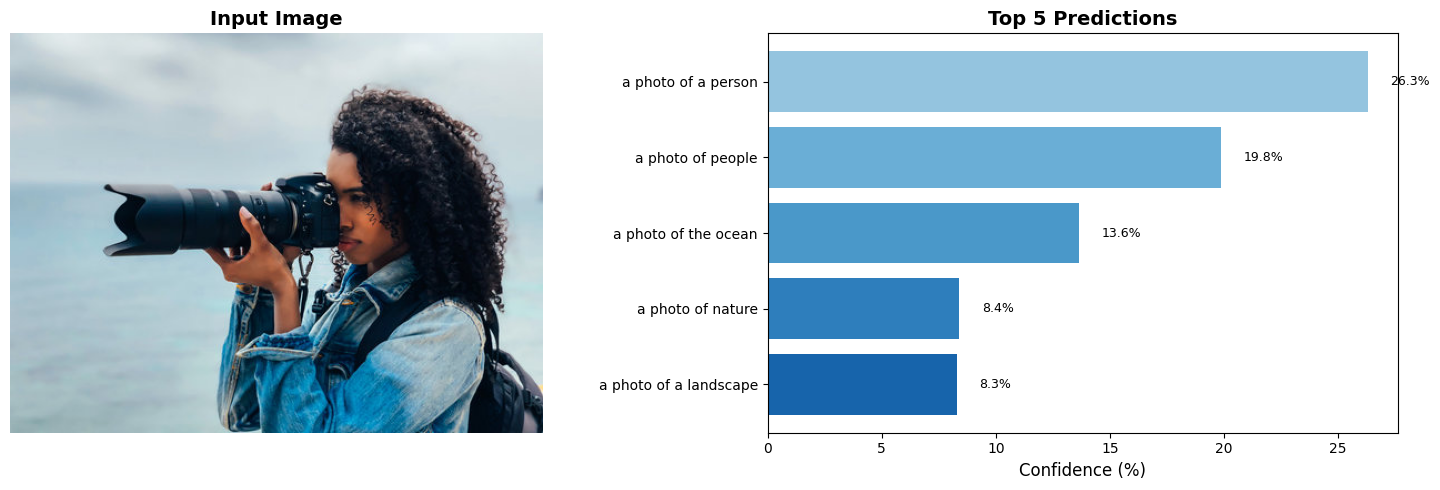


CAPTION RESULTS:
1. a photo of a person: 26.29%
2. a photo of people: 19.85%
3. a photo of the ocean: 13.65%
4. a photo of nature: 8.40%
5. a photo of a landscape: 8.28%


In [62]:
from google.colab import files
import io

# Upload image
print("Upload an image file:")
uploaded = files.upload()

# Get the uploaded file
for filename in uploaded.keys():
    image = Image.open(io.BytesIO(uploaded[filename])).convert('RGB')
    print(f"\nProcessing: {filename}")

    # Generate captions with default prompts
    prompts, values, indices = generate_caption(image)
    visualize_results(image, prompts, values, indices)

Upload an image file:


Saving image1.jpg to image1.jpg

Processing: image1.jpg


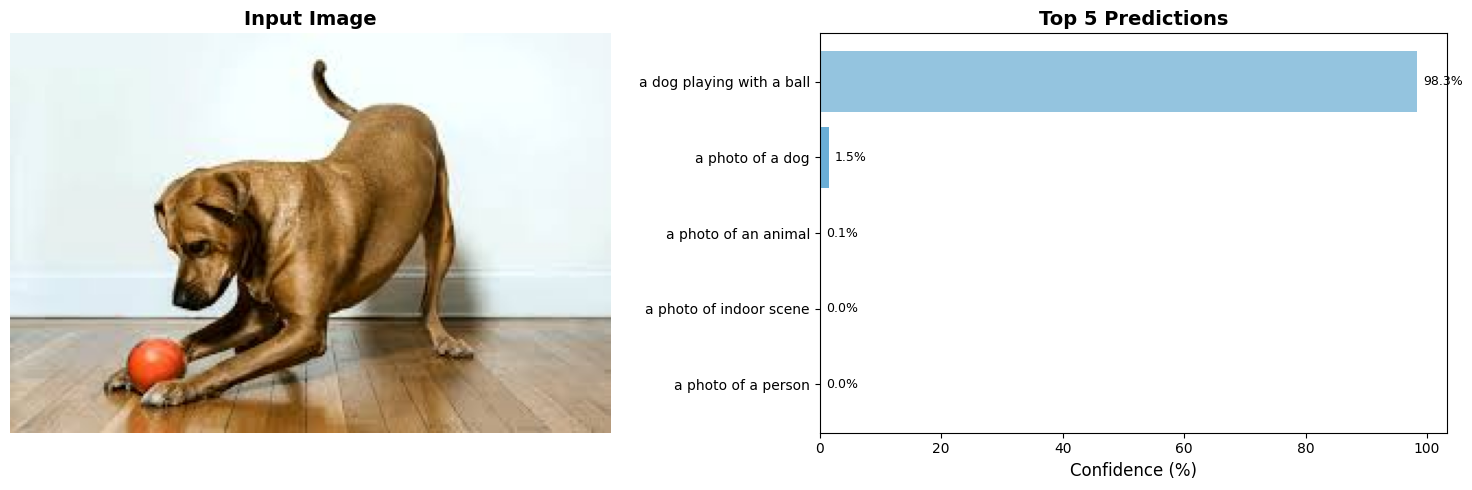


CAPTION RESULTS:
1. a dog playing with a ball: 98.34%
2. a photo of a dog: 1.49%
3. a photo of an animal: 0.13%
4. a photo of indoor scene: 0.01%
5. a photo of a person: 0.00%


In [61]:
from google.colab import files
import io

# Upload image
print("Upload an image file:")
uploaded = files.upload()

# Get the uploaded file
for filename in uploaded.keys():
    image = Image.open(io.BytesIO(uploaded[filename])).convert('RGB')
    print(f"\nProcessing: {filename}")

    # Generate captions with default prompts
    prompts, values, indices = generate_caption(image)
    visualize_results(image, prompts, values, indices)

Upload an image file:


Saving imag2.webp to imag2.webp

Processing: imag2.webp


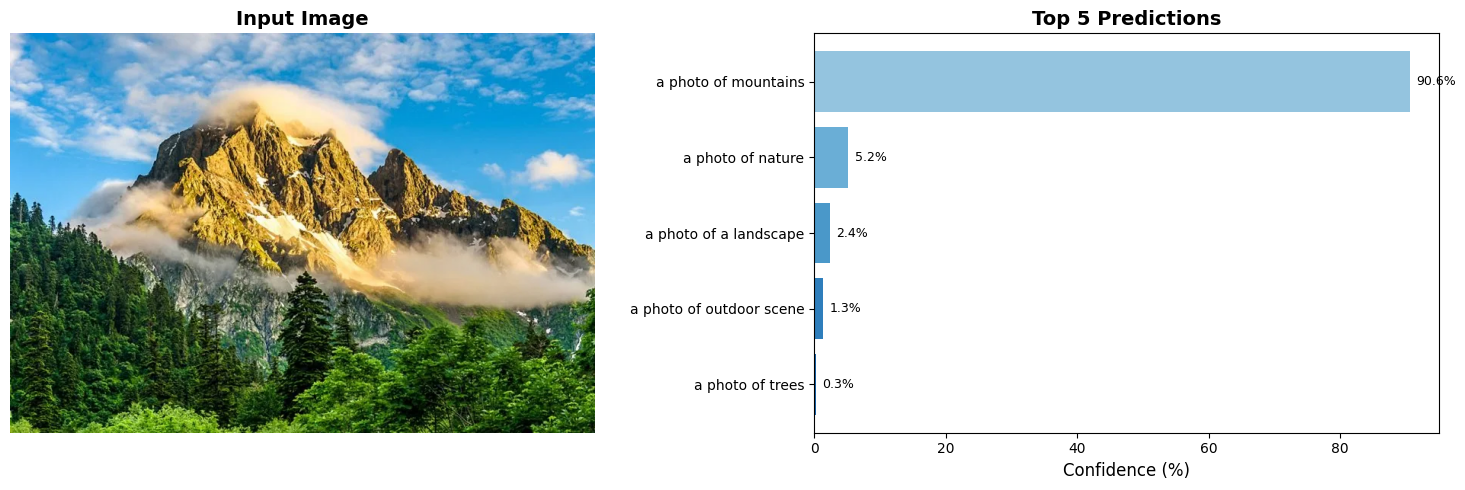


CAPTION RESULTS:
1. a photo of mountains: 90.58%
2. a photo of nature: 5.19%
3. a photo of a landscape: 2.38%
4. a photo of outdoor scene: 1.31%
5. a photo of trees: 0.26%


In [63]:
from google.colab import files
import io

# Upload image
print("Upload an image file:")
uploaded = files.upload()

# Get the uploaded file
for filename in uploaded.keys():
    image = Image.open(io.BytesIO(uploaded[filename])).convert('RGB')
    print(f"\nProcessing: {filename}")

    # Generate captions with default prompts
    prompts, values, indices = generate_caption(image)
    visualize_results(image, prompts, values, indices)

Upload an image file:


Saving images (1).jpg to images (1).jpg

Processing: images (1).jpg


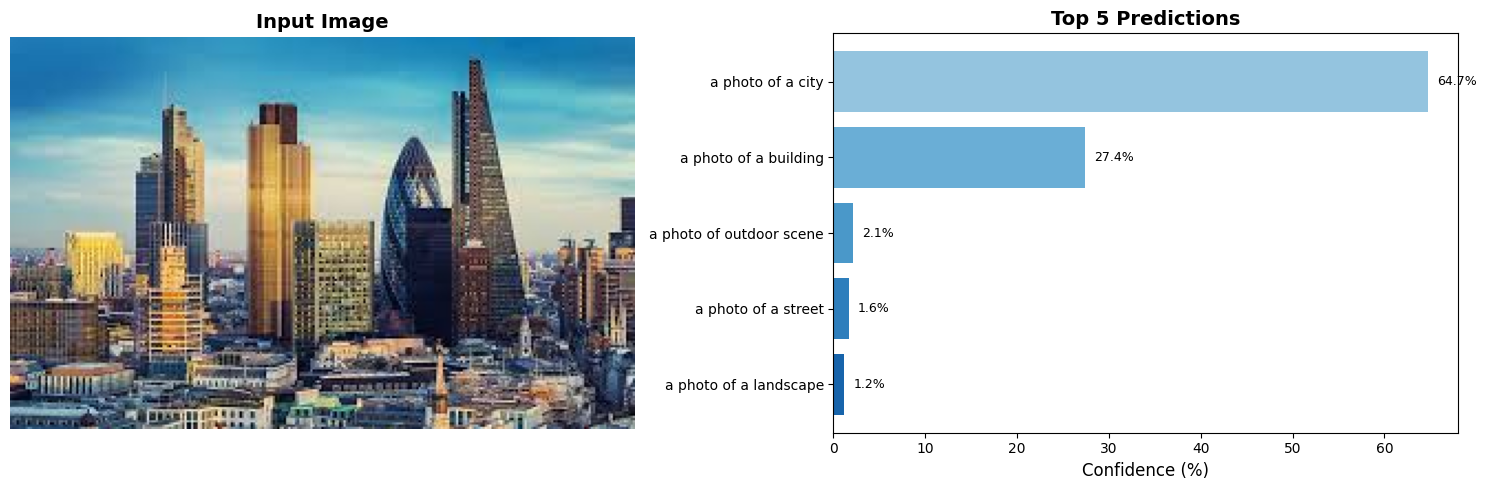


CAPTION RESULTS:
1. a photo of a city: 64.75%
2. a photo of a building: 27.42%
3. a photo of outdoor scene: 2.15%
4. a photo of a street: 1.65%
5. a photo of a landscape: 1.17%


In [64]:
from google.colab import files
import io

# Upload image
print("Upload an image file:")
uploaded = files.upload()

# Get the uploaded file
for filename in uploaded.keys():
    image = Image.open(io.BytesIO(uploaded[filename])).convert('RGB')
    print(f"\nProcessing: {filename}")

    # Generate captions with default prompts
    prompts, values, indices = generate_caption(image)
    visualize_results(image, prompts, values, indices)